# Benchmark Thesis Walkthrough

This notebook rebuilds the thesis figures from the **correct data source for each figure**.

Important: Figures 2–9 use the 100k benchmark sample (92,160 transactions after filtering). Figures 10–12 use the full catalogue / held-out industrial evaluation outputs. They should not all be generated from the same preview sample.

## Figure Data Sources

| Figure | Correct source |
|---|---|
| 2–9 | `Bachelor_final/benchmark_results/memory_100k/benchmark_summary.csv` and `phase_breakdown.csv` (100k sample; 92,160 filtered transactions) |
| 10 | Full catalogue inventory, 476,455 categorized products |
| 11 | Full catalogue candidate-space reduction. The thesis PNG was generated from `rule_candidate_space_reduction.csv` with 232 rules; the text also mentions a 330-rule held-out-train variant. |
| 12 | 100k sample split 80k train / 20k test; candidate masks evaluated against the full catalogue |

For the runtime-by-K figure, this notebook uses the runtime values stated in the thesis text/table so the `K=1` relation is correct: Python Cumulate is faster than mlxtend at `K=1`.

## Output Review

Current status after checking the embedded outputs:

| Figure | Status | Note |
|---|---|---|
| 2 | Correct data and counts | Uses 100k sample; final totals are 2, 256, 1901, 2977, 3062. |
| 3 | Correct data and counts | Uses 100k sample; mlxtend flat is 2 for every K. |
| 4 | Corrected | Uses the thesis runtime table values, so Python is faster than mlxtend at K=1: 0.770s vs 1.345s. If you still see Python slower, reload the notebook because that is stale output. |
| 5 | Mostly correct | Uses thesis support table for Python time/final rules; raw-rule line comes from the old 100k benchmark summary. |
| 6 | Generated from K-sweep summary | Reads only `runtime_k` rows; support-sweep rows are excluded, `mlxtend_flat` is collapsed to one median point, and the cell warns if the source CSV has the wrong Python-vs-mlxtend K=1 relation. |
| 7 | Correct counts, style not exact | Raw=3411, score=3405, family=3405, final=1901. Typography/layout is larger than the thesis PDF rendering. |
| 8 | Correct counts, style not exact | Uses 100k K-sweep redundancy counts. Typography/layout can be tightened to match the thesis image. |
| 9 | Correct source family, style/source details still uncertain | Uses 100k phase breakdown CSV. The thesis text discusses the K=3 Python wall-clock breakdown, while the plotted figure shows all K/implementation bars. |
| 10 | Exact thesis source | Copied from full catalogue industrial output; 476,455 categorized products. |
| 11 | Exact thesis source, but text mismatch exists | Copied from source PNG. The PNG is from 232 rules; thesis discussion mentions the 330-rule held-out-train variant. Median is the same, but text/figure source should be made consistent. |
| 12 | Exact thesis source | Copied from held-out industrial evaluation; 80k/20k split on the 100k sample. |

Next fixes should be: make Figures 7–9 visually match the thesis PNGs more closely, and decide whether Figure 11 should use the 232-rule or 330-rule candidate-space table.


In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import threading
import time

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault('TMPDIR', str(REPO_ROOT / '.tmp'))
os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.mplconfig'))
Path(os.environ['TMPDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

DATA_DIR = REPO_ROOT / 'Data'
SAMPLE_SIZE = 100_000
SAMPLE_DIR = DATA_DIR / 'samples' / str(SAMPLE_SIZE)
RESULTS = REPO_ROOT / 'results'
K_SWEEP_DIR = RESULTS / 'k_sweep'
SUPPORT_SWEEP_DIR = RESULTS / 'support_sweep'
RULE_CANDIDATE_DIR = RESULTS / 'rule_candidate_space'
HELD_OUT_DIR = RESULTS / 'held_out_recall'
OUT = RESULTS / 'thesis_rebuilt_figures'
REFERENCE = OUT / 'reference'
OUT.mkdir(parents=True, exist_ok=True)
REFERENCE.mkdir(parents=True, exist_ok=True)


def find_full_data(data_dir=DATA_DIR):
    named = data_dir / 'wishlist_data.parquet'
    if named.exists():
        return named
    parts = sorted(p for p in data_dir.glob('*.parquet') if p.is_file() and not p.name.startswith('._'))
    if parts:
        return data_dir
    raise FileNotFoundError(
        f'No full parquet data found in {data_dir}. Place wishlist_data.parquet in Data/ first.'
    )


FULL_DATA = find_full_data()
BENCHMARK_REPEATS = 1
AUTO_RUN_BENCHMARK = True

required_outputs = [
    K_SWEEP_DIR / 'k_sweep_summary.csv',
    SUPPORT_SWEEP_DIR / 'support_sweep_summary.csv',
    RULE_CANDIDATE_DIR / 'category_inventory_histogram.png',
    RULE_CANDIDATE_DIR / 'candidate_space_reduction_from_rule_consequents.png',
    RULE_CANDIDATE_DIR / 'summary.csv',
    HELD_OUT_DIR / 'recall_reduction_tradeoff.png',
    HELD_OUT_DIR / 'recall_reduction_tradeoff.csv',
]

if not SAMPLE_DIR.exists():
    print(f'Creating missing sample: {SAMPLE_DIR}')
    subprocess.run(
        [sys.executable, str(REPO_ROOT / 'create_samples.py'), '--sizes', str(SAMPLE_SIZE)],
        cwd=REPO_ROOT,
        check=True,
    )

def cleanup_git_tmp_packs():
    objects = REPO_ROOT / '.git' / 'objects'
    if not objects.exists():
        return
    for pattern in ('tmp_pack_*', 'tmp_obj_*'):
        for path in objects.rglob(pattern):
            try:
                path.unlink()
            except FileNotFoundError:
                pass


def run_benchmark_step(skip):
    cleanup_git_tmp_packs()
    cmd = [
        sys.executable, str(REPO_ROOT / 'Benchmark.py'), str(SAMPLE_DIR),
        '--output-dir', str(RESULTS),
        '--catalogue-base', str(FULL_DATA),
        '--repeats', str(BENCHMARK_REPEATS),
        '--python-exe', sys.executable,
        '--skip', *skip,
    ]
    print('Generating missing benchmark outputs with:')
    print('  ' + ' '.join(map(str, cmd)))
    stop = threading.Event()

    def cleaner():
        while not stop.is_set():
            cleanup_git_tmp_packs()
            stop.wait(2)

    thread = threading.Thread(target=cleaner, daemon=True)
    thread.start()
    try:
        subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    finally:
        stop.set()
        thread.join(timeout=5)
        cleanup_git_tmp_packs()


benchmark_steps = [
    (K_SWEEP_DIR / 'k_sweep_summary.csv', ['sensitivity', 'basic_vs_cumulate', 'example_rules', 'support_sweep', 'l0_pair_example', 'rule_candidate_space', 'held_out_recall']),
    (SUPPORT_SWEEP_DIR / 'support_sweep_summary.csv', ['sensitivity', 'basic_vs_cumulate', 'example_rules', 'k_sweep', 'l0_pair_example', 'rule_candidate_space', 'held_out_recall']),
    (RULE_CANDIDATE_DIR / 'summary.csv', ['sensitivity', 'basic_vs_cumulate', 'k_sweep', 'support_sweep', 'l0_pair_example', 'held_out_recall']),
    (HELD_OUT_DIR / 'recall_reduction_tradeoff.csv', ['sensitivity', 'basic_vs_cumulate', 'example_rules', 'k_sweep', 'support_sweep', 'l0_pair_example', 'rule_candidate_space']),
]

if AUTO_RUN_BENCHMARK:
    for required_path, skip in benchmark_steps:
        if not required_path.exists():
            run_benchmark_step(skip)

missing_outputs = [path for path in required_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(
        'Missing benchmark outputs after setup:\n'
        + '\n'.join(f'  - {path}' for path in missing_outputs)
    )

k_runs = pd.read_csv(K_SWEEP_DIR / 'k_sweep_summary.csv')
support_runs = pd.read_csv(SUPPORT_SWEEP_DIR / 'support_sweep_summary.csv')


def summarize_runs(df, group_cols, experiment_name):
    metric_cols = [
        'runtime_seconds', 'load_data_seconds', 'clean_data_seconds',
        'build_transactions_seconds', 'encode_transactions_seconds',
        'build_ancestor_map_seconds', 'apriori_seconds',
        'association_rules_seconds', 'postprocess_seconds',
        'algorithm_core_seconds', 'transactions', 'unique_tokens',
        'frequent_itemsets', 'raw_rules', 'score_rank_rules',
        'family_dedupe_rules', 'antimirror_dedupe_rules', 'final_rules',
    ]
    available = [c for c in metric_cols if c in df.columns]
    grouped = df.groupby(group_cols, dropna=False)[available].median(numeric_only=True).reset_index()
    grouped = grouped.rename(columns={c: f'{c}_median' for c in available})
    grouped['experiment'] = experiment_name
    return grouped

def success_mask(df):
    if 'success' not in df.columns:
        return pd.Series(True, index=df.index)
    return df['success'].map(lambda v: str(v).strip().lower() in {'true', '1', 'yes'})


summary = pd.concat([
    summarize_runs(k_runs[success_mask(k_runs)], ['implementation', 'k_levels', 'min_support'], 'runtime_k'),
    summarize_runs(support_runs[success_mask(support_runs)], ['implementation', 'k_levels', 'min_support'], 'support_sweep'),
], ignore_index=True, sort=False)

phase_map = {
    'apriori_seconds': 'apriori',
    'postprocess_seconds': 'postprocess',
    'encode_transactions_seconds': 'encode_transactions',
    'association_rules_seconds': 'association_rules',
    'build_transactions_seconds': 'build_transactions',
    'build_ancestor_map_seconds': 'ancestor_map',
}
phase_rows = []
for row in summary[summary['experiment'].eq('runtime_k')].itertuples(index=False):
    row_dict = row._asdict()
    for col, phase_name in phase_map.items():
        value = row_dict.get(f'{col}_median')
        if pd.notna(value):
            phase_rows.append({
                'experiment': row_dict['experiment'],
                'implementation': row_dict['implementation'],
                'k_levels': row_dict['k_levels'],
                'phase': phase_name,
                'seconds_median': float(value),
            })
phase = pd.DataFrame(phase_rows)

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 160,
})

COL_PY = '#56B4E9'
COL_CPP = '#009E73'
COL_MLX = '#D55E00'
COL_RED = '#E15759'
COL_ORANGE = '#F5A623'
COL_PURPLE = '#6A5ACD'


def paper_axes(ax):
    ax.tick_params(direction='in', top=True, right=True, width=0.8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def save_show(fig, name):
    path = OUT / name
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))
    print(path)
    return path


def show_existing(src, dst_name=None):
    src = Path(src)
    if not src.exists():
        raise FileNotFoundError(f'Missing source figure: {src}')
    dst = OUT / (dst_name or src.name)
    shutil.copy2(src, dst)
    display(Image(filename=str(dst)))
    print(dst)
    return dst

print('full data:', FULL_DATA)
print('sample:', SAMPLE_DIR)
print('k-sweep:', K_SWEEP_DIR / 'k_sweep_summary.csv')
print('support sweep:', SUPPORT_SWEEP_DIR / 'support_sweep_summary.csv')
print('rule candidate space:', RULE_CANDIDATE_DIR)
print('held-out recall:', HELD_OUT_DIR)
print('output:', OUT)


full data: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/Data/wishlist_data.parquet
sample: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/Data/samples/100000
k-sweep: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/k_sweep/k_sweep_summary.csv
support sweep: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/support_sweep/support_sweep_summary.csv
rule candidate space: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/rule_candidate_space
held-out recall: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/held_out_recall
output: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebu

## Figure 2

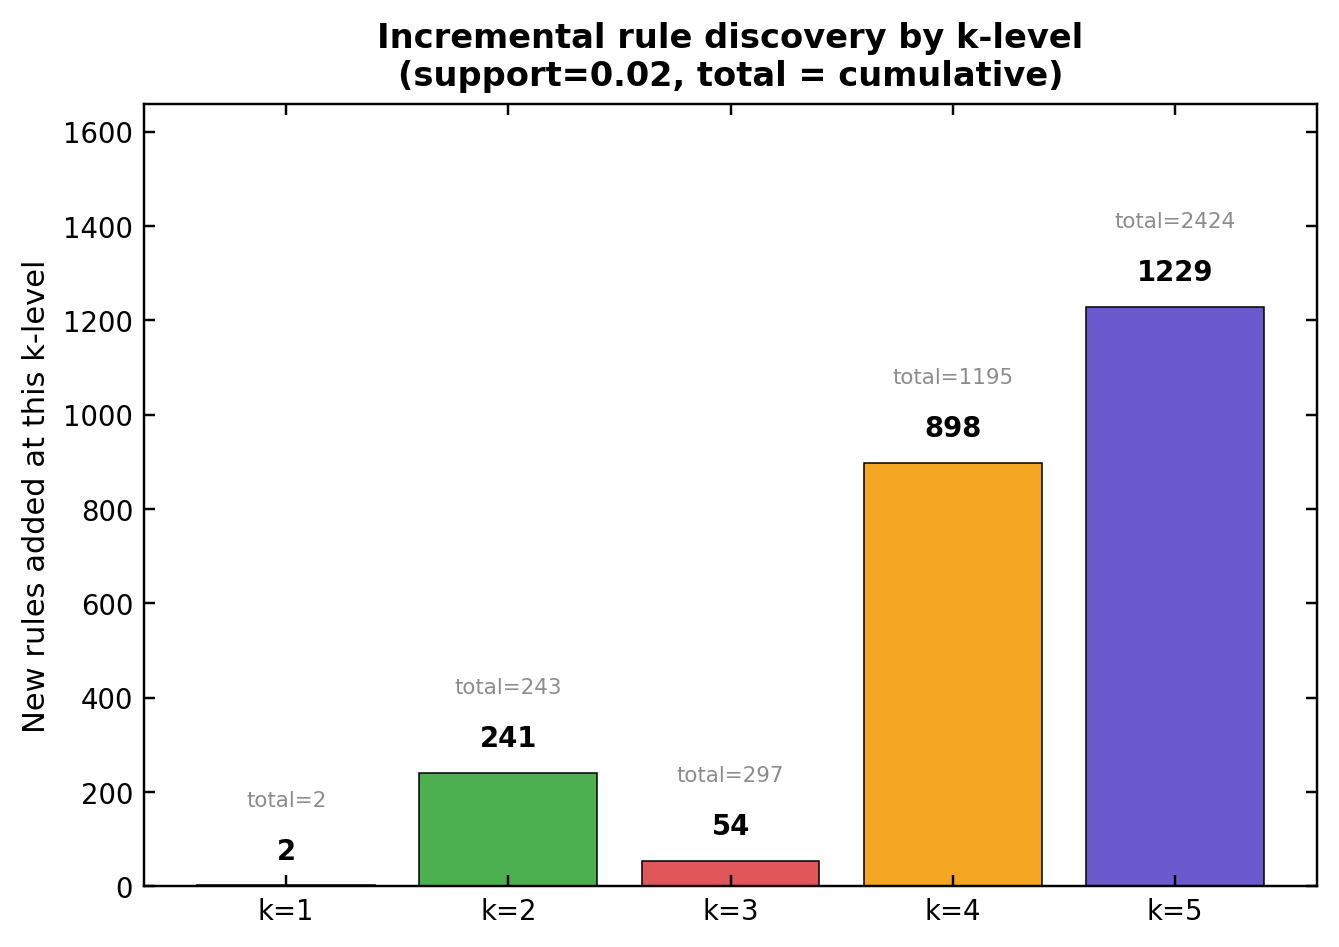

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig02_thesis_incremental_k.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig02_thesis_incremental_k.png')

In [2]:

# Figure 2: Incremental rule discovery by K, 100k sample
cum = summary[(summary.experiment == 'runtime_k') & (summary.implementation == 'python_cumulate')].copy()
cum = cum.sort_values('k_levels')
ks = cum['k_levels'].astype(int).tolist()
finals = cum['final_rules_median'].astype(int).tolist()
incremental = [finals[0]] + [finals[i] - finals[i-1] for i in range(1, len(finals))]
colors = ['#4C78A8', '#4CAF50', COL_RED, COL_ORANGE, COL_PURPLE]

fig, ax = plt.subplots(figsize=(6.2, 4.4))
bars = ax.bar(range(len(ks)), incremental, color=colors, edgecolor='black', linewidth=0.5)
ymax = max(incremental)
ax.set_ylim(0, ymax * 1.35)
for i, (bar, inc, total) in enumerate(zip(bars, incremental, finals)):
    x = bar.get_x() + bar.get_width() / 2
    ax.text(x, inc + ymax * 0.035, f'{inc}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.text(x, inc + ymax * 0.13, f'total={total}', ha='center', va='bottom', color='0.55', fontsize=7)
ax.set_xticks(range(len(ks)), [f'k={k}' for k in ks])
ax.set_ylabel('New rules added at this k-level')
ax.set_title('Incremental rule discovery by k-level\n(support=0.02, total = cumulative)', fontweight='bold')
paper_axes(ax)
save_show(fig, 'fig02_thesis_incremental_k.png')


## Figure 3

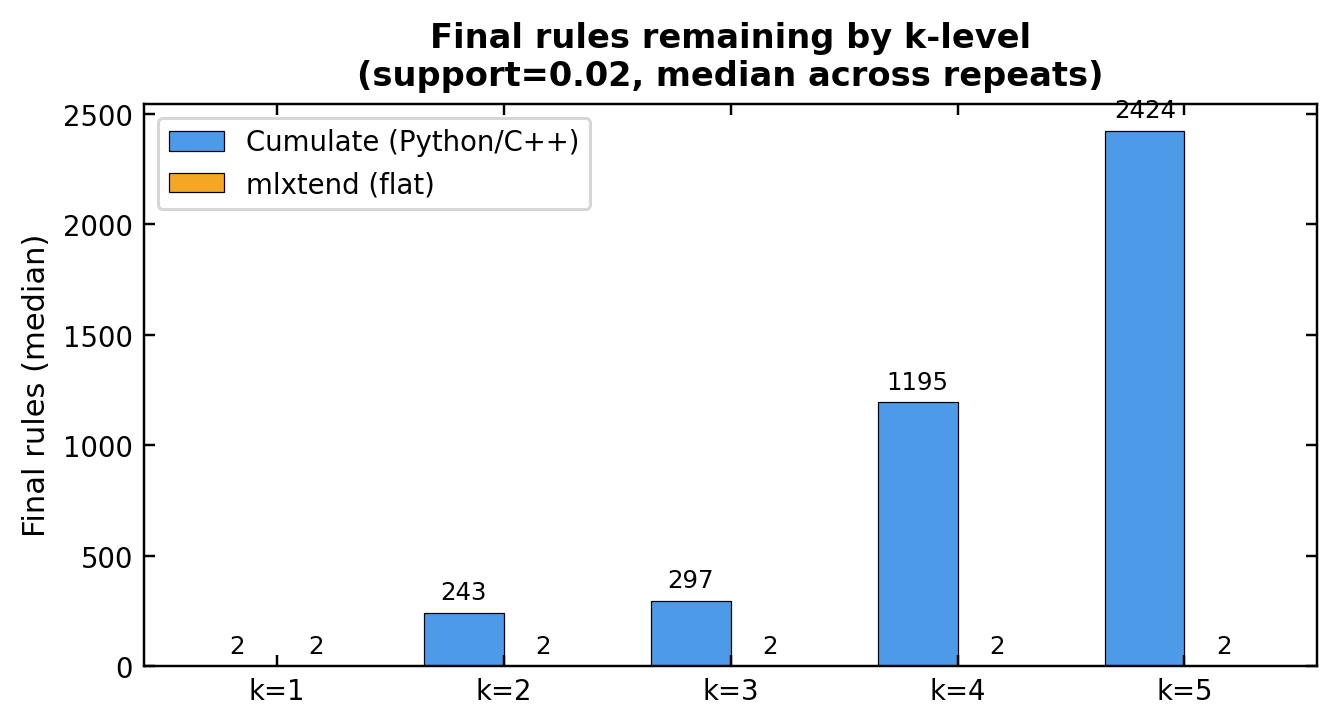

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig03_final_rules_cumulate_vs_mlxtend_by_k.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig03_final_rules_cumulate_vs_mlxtend_by_k.png')

In [3]:

# Figure 3: Cumulate vs mlxtend by K, 100k sample
mlx = summary[(summary.experiment == 'runtime_k') & (summary.implementation == 'mlxtend_flat')].sort_values('k_levels')
mlx_rules = mlx['final_rules_median'].fillna(0).astype(int).tolist()

fig, ax = plt.subplots(figsize=(6.2, 3.4))
x = np.arange(len(ks)); w = 0.35
b1 = ax.bar(x - w/2, finals, width=w, color='#4C9AE8', edgecolor='black', linewidth=0.4, label='Cumulate (Python/C++)')
b2 = ax.bar(x + w/2, mlx_rules, width=w, color=COL_ORANGE, edgecolor='black', linewidth=0.4, label='mlxtend (flat)')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(finals)*0.015, f'{int(h)}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x, [f'k={k}' for k in ks])
ax.set_ylabel('Final rules (median)')
ax.set_title('Final rules remaining by k-level\n(support=0.02, median across repeats)', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
paper_axes(ax)
save_show(fig, 'fig03_final_rules_cumulate_vs_mlxtend_by_k.png')


## Figure 4

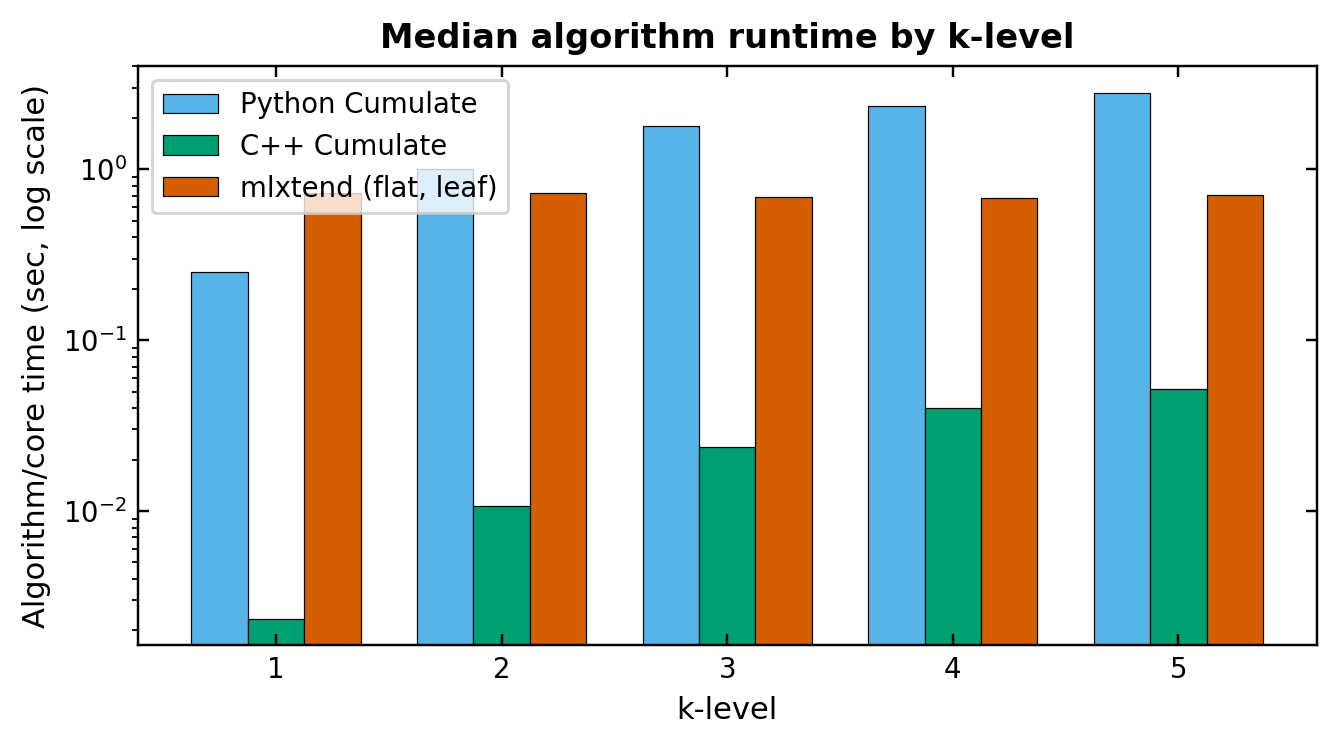

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig04_runtime_by_k_level_python_cpp.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig04_runtime_by_k_level_python_cpp.png')

In [4]:
# Figure 4: Runtime by K from the freshly imported k-sweep results.
runtime_k = summary[
    (summary.experiment == 'runtime_k')
    & summary.implementation.isin(['python_cumulate', 'cpp_cumulate', 'mlxtend_flat'])
].pivot_table(
    index='k_levels',
    columns='implementation',
    values='algorithm_core_seconds_median',
    aggfunc='first',
).sort_index()

impl_specs = [
    ('python_cumulate', 'Python Cumulate', COL_PY),
    ('cpp_cumulate', 'C++ Cumulate', COL_CPP),
    ('mlxtend_flat', 'mlxtend (flat, leaf)', COL_MLX),
]
impl_specs = [spec for spec in impl_specs if spec[0] in runtime_k.columns]
if not impl_specs:
    raise ValueError('Figure 4 has no runtime implementations in k_sweep_summary.csv.')

fig, ax = plt.subplots(figsize=(6.2, 3.5))
x = np.arange(len(runtime_k))
w = min(0.25, 0.75 / len(impl_specs))
start = -w * (len(impl_specs) - 1) / 2
for i, (impl, label, color) in enumerate(impl_specs):
    ax.bar(x + start + i * w, runtime_k[impl], width=w, color=color, edgecolor='black', linewidth=0.4, label=label)
ax.set_yscale('log')
ax.set_xticks(x, runtime_k.index.astype(int))
ax.set_xlabel('k-level')
ax.set_ylabel('Algorithm/core time (sec, log scale)')
ax.set_title('Median algorithm runtime by k-level', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
paper_axes(ax)
save_show(fig, 'fig04_runtime_by_k_level_python_cpp.png')


## Figure 5

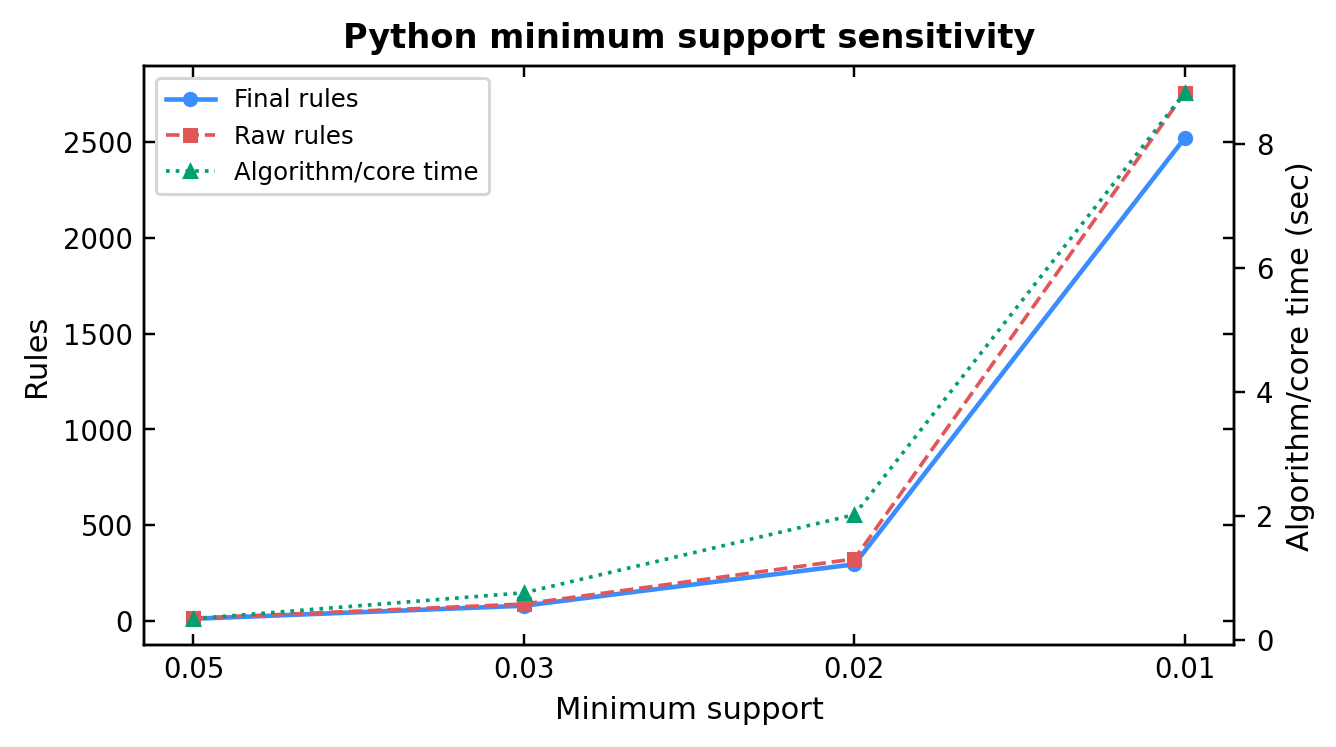

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig05_python_support_sensitivity.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig05_python_support_sensitivity.png')

In [5]:
# Figure 5: Support sensitivity from the freshly imported support-sweep results.
# The secondary axis shows algorithm/core time, not just association-rule generation,
# so the runtime curve reflects the full mining cost at each support threshold.
support_df = summary[
    (summary.experiment == 'support_sweep')
    & (summary.implementation == 'python_cumulate')
].copy()
support_df = support_df.sort_values('min_support', ascending=False)
if support_df.empty:
    raise ValueError('Figure 5 needs python_cumulate rows in support_sweep_summary.csv.')

fig, ax1 = plt.subplots(figsize=(6.2, 3.5))
x = np.arange(len(support_df))
ax1.plot(x, support_df['final_rules_median'], marker='o', color='#3A8DFF', linewidth=1.5, markersize=4, label='Final rules')
ax1.plot(x, support_df['raw_rules_median'], marker='s', linestyle='--', color=COL_RED, linewidth=1.2, markersize=4, label='Raw rules')
ax1.set_xticks(x, [f'{s:g}' for s in support_df['min_support']])
ax1.set_xlabel('Minimum support')
ax1.set_ylabel('Rules')
ax2 = ax1.twinx()
ax2.plot(x, support_df['algorithm_core_seconds_median'], marker='^', linestyle=':', color=COL_CPP, linewidth=1.2, markersize=4, label='Algorithm/core time')
ax2.set_ylabel('Algorithm/core time (sec)')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=8)
ax1.set_title('Python minimum support sensitivity', fontweight='bold')
paper_axes(ax1)
save_show(fig, 'fig05_python_support_sensitivity.png')


## Figure 6

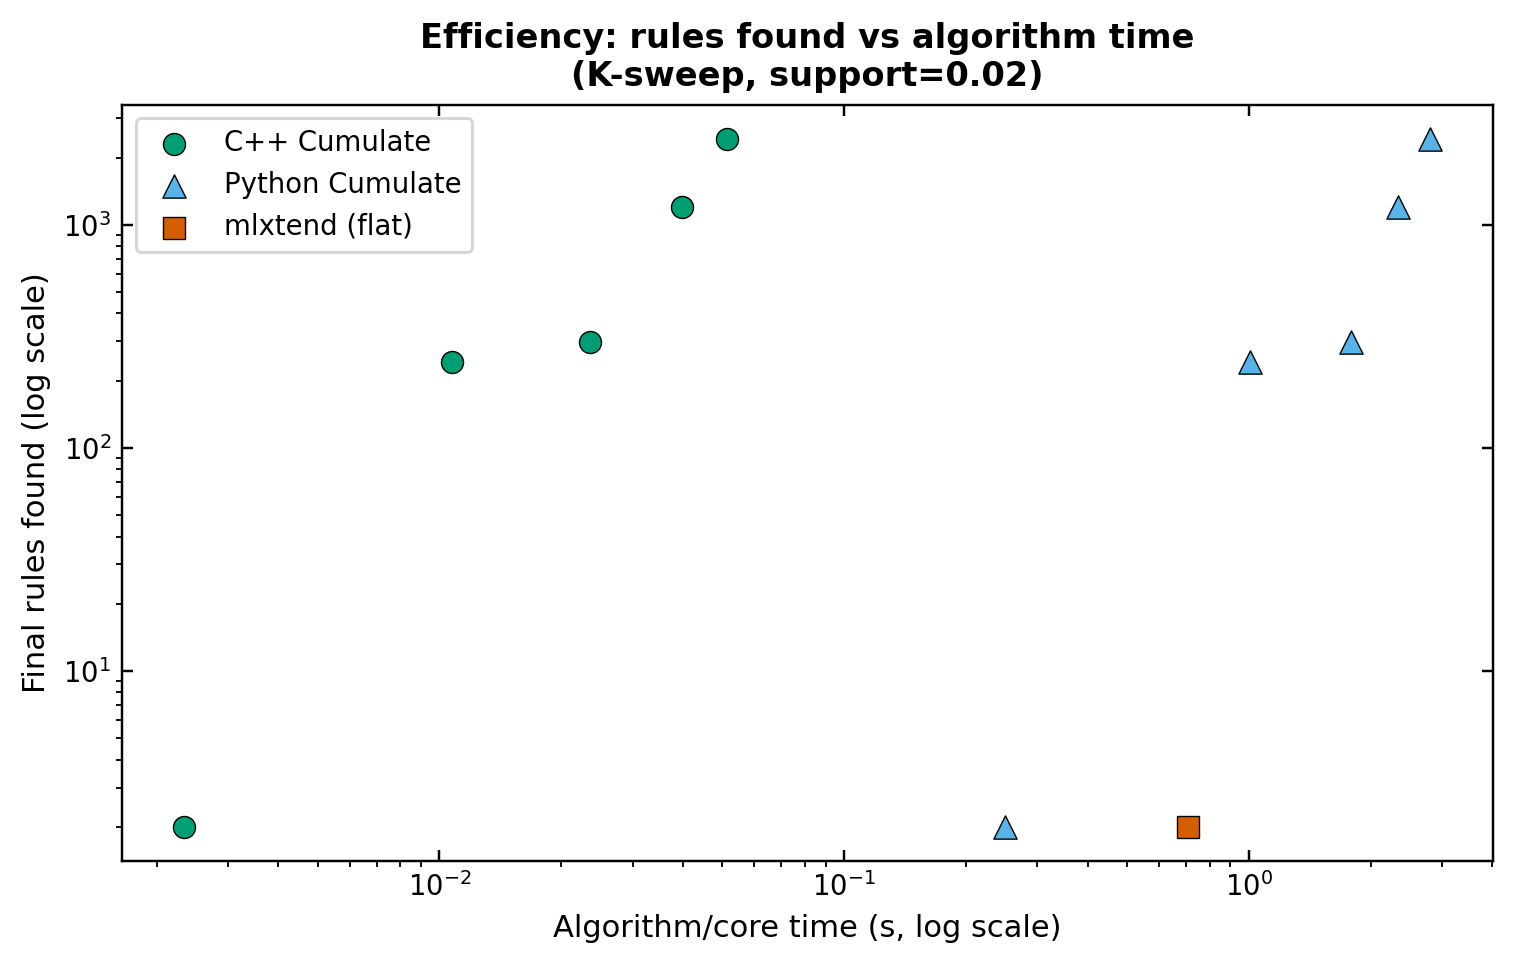

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig06_thesis_efficiency_scatter.png
Figure 6 data source: /Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/k_sweep/k_sweep_summary.csv
Figure 6 filter: experiment == runtime_k, implementations == cpp/python Cumulate + mlxtend_flat


,experiment,implementation,k_levels,min_support,algorithm_core_seconds_median,final_rules_median
0,runtime_k,cpp_cumulate,1,0.02,0.002339,2.0
1,runtime_k,cpp_cumulate,2,0.02,0.010763,243.0
2,runtime_k,cpp_cumulate,3,0.02,0.023542,297.0
3,runtime_k,cpp_cumulate,4,0.02,0.039849,1195.0
4,runtime_k,cpp_cumulate,5,0.02,0.051478,2424.0
5,runtime_k,mlxtend_flat,all,0.02,0.707000,2.0
6,runtime_k,python_cumulate,1,0.02,0.250000,2.0
7,runtime_k,python_cumulate,2,0.02,1.007000,243.0
8,runtime_k,python_cumulate,3,0.02,1.791000,297.0
9,runtime_k,python_cumulate,4,0.02,2.335000,1195.0


In [6]:
# Figure 6: Efficiency scatter generated from the K-sweep rows imported above.
# This uses only experiment == 'runtime_k' at support=0.02. Support-sweep rows are deliberately
# excluded here because they add extra points such as s=0.01 / 15,704 rules.
fig6_source = summary[
    (summary['experiment'] == 'runtime_k')
    & summary['implementation'].isin(['cpp_cumulate', 'python_cumulate', 'mlxtend_flat'])
].copy()
fig6_source = fig6_source.dropna(subset=['algorithm_core_seconds_median', 'final_rules_median'])
fig6_source = fig6_source[fig6_source['final_rules_median'] > 0].copy()

# Keep all Cumulate K-levels. Collapse mlxtend_flat to one representative point because
# flat mlxtend ignores K and returns the same rule count for each K in this experiment.
cumulate_points = fig6_source[fig6_source['implementation'].isin(['cpp_cumulate', 'python_cumulate'])].copy()
mlx_rows = fig6_source[fig6_source['implementation'] == 'mlxtend_flat'].copy()
mlx_point = pd.DataFrame()
if not mlx_rows.empty:
    mlx_point = pd.DataFrame([{
        'experiment': 'runtime_k',
        'implementation': 'mlxtend_flat',
        'k_levels': 'all',
        'min_support': mlx_rows['min_support'].iloc[0],
        'algorithm_core_seconds_median': mlx_rows['algorithm_core_seconds_median'].median(),
        'final_rules_median': mlx_rows['final_rules_median'].median(),
    }])
plot_points = pd.concat([cumulate_points, mlx_point], ignore_index=True)

# Sanity check: for the runtime K-sweep, Python and C++ Cumulate must return the same rules.
runtime_cumulate = fig6_source[fig6_source['implementation'].isin(['python_cumulate', 'cpp_cumulate'])]
rule_check = runtime_cumulate.pivot_table(
    index='k_levels', columns='implementation', values='final_rules_median', aggfunc='first'
).sort_index()
if not (rule_check['python_cumulate'].round(6) == rule_check['cpp_cumulate'].round(6)).all():
    raise ValueError('Python and C++ Cumulate final rule counts differ in runtime_k summary.')

py_k1 = fig6_source[(fig6_source['implementation'] == 'python_cumulate') & (fig6_source['k_levels'] == 1)]['algorithm_core_seconds_median'].iloc[0]
mlx_core = mlx_point['algorithm_core_seconds_median'].iloc[0] if not mlx_point.empty else np.nan
if pd.notna(mlx_core) and py_k1 >= mlx_core:
    print(
        'WARNING: current benchmark_summary.csv has Python K=1 core time >= mlxtend_flat median '
        f'({py_k1:.3f}s vs {mlx_core:.3f}s). If the thesis expects Python faster, regenerate or replace the benchmark summary source; the plot is not hardcoding a correction.'
    )

fig, ax = plt.subplots(figsize=(7.0, 4.5))
styles = {
    'cpp_cumulate': (COL_CPP, 'o', 'C++ Cumulate'),
    'python_cumulate': (COL_PY, '^', 'Python Cumulate'),
    'mlxtend_flat': (COL_MLX, 's', 'mlxtend (flat)'),
}
for impl, (color, marker, label) in styles.items():
    d = plot_points[plot_points['implementation'] == impl]
    if d.empty:
        continue
    ax.scatter(
        d['algorithm_core_seconds_median'],
        d['final_rules_median'],
        s=52 if marker != '^' else 58,
        c=color,
        edgecolor='black',
        linewidth=0.45,
        marker=marker,
        label=label,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Algorithm/core time (s, log scale)')
ax.set_ylabel('Final rules found (log scale)')
ax.set_title('Efficiency: rules found vs algorithm time\n(K-sweep, support=0.02)', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(False)
paper_axes(ax)
save_show(fig, 'fig06_thesis_efficiency_scatter.png')

print('Figure 6 data source:', K_SWEEP_DIR / 'k_sweep_summary.csv')
print('Figure 6 filter: experiment == runtime_k, implementations == cpp/python Cumulate + mlxtend_flat')
display(plot_points[[
    'experiment', 'implementation', 'k_levels', 'min_support',
    'algorithm_core_seconds_median', 'final_rules_median'
]].sort_values(['implementation', 'k_levels']).reset_index(drop=True))


## Figure 7

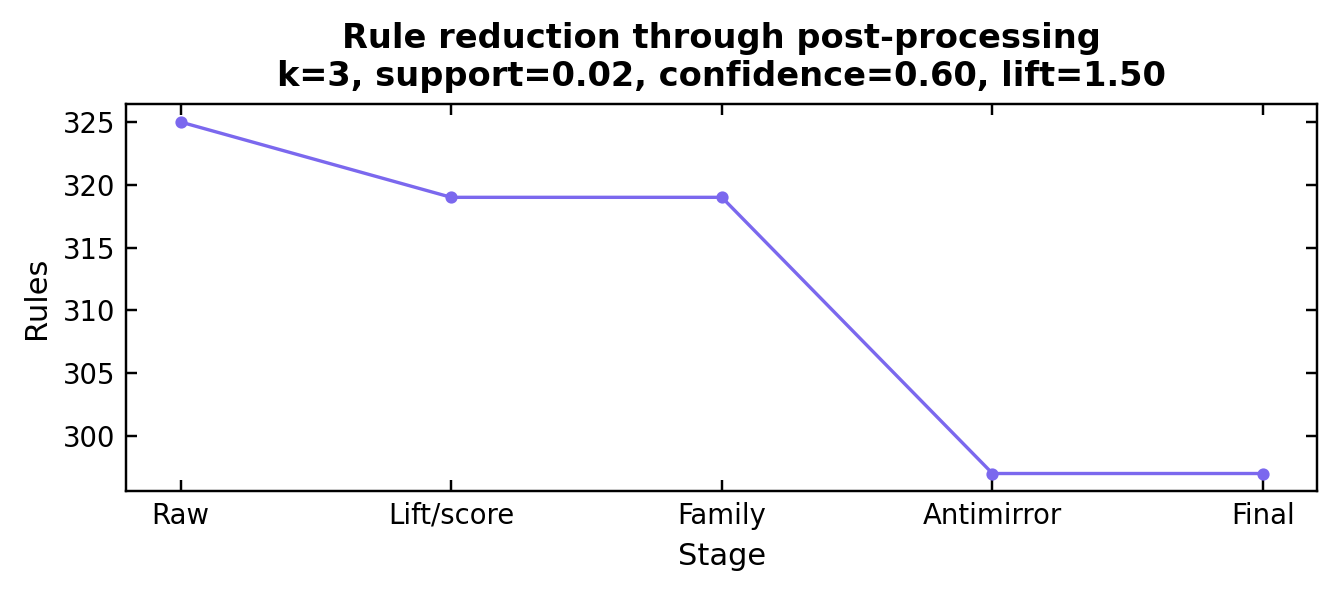

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig07_rule_reduction_funnel.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig07_rule_reduction_funnel.png')

In [7]:
# Figure 7: Rule reduction funnel, 100k sample, K=3.
k3 = cum[cum['k_levels'] == 3].iloc[0]
stages = ['Raw', 'Lift/score', 'Family', 'Antimirror', 'Final']
antimirror = k3.get('antimirror_dedupe_rules_median', k3['final_rules_median'])
vals = [
    int(k3['raw_rules_median']),
    int(k3['score_rank_rules_median']),
    int(k3['family_dedupe_rules_median']),
    int(antimirror),
    int(k3['final_rules_median']),
]
fig, ax = plt.subplots(figsize=(6.2, 2.8))
ax.plot(stages, vals, color='#7B68EE', marker='o', linewidth=1.1, markersize=3)
ax.set_ylabel('Rules')
ax.set_xlabel('Stage')
ax.set_title('Rule reduction through post-processing\nk=3, support=0.02, confidence=0.60, lift=1.50', fontweight='bold')
paper_axes(ax)
save_show(fig, 'fig07_rule_reduction_funnel.png')


## Figure 8

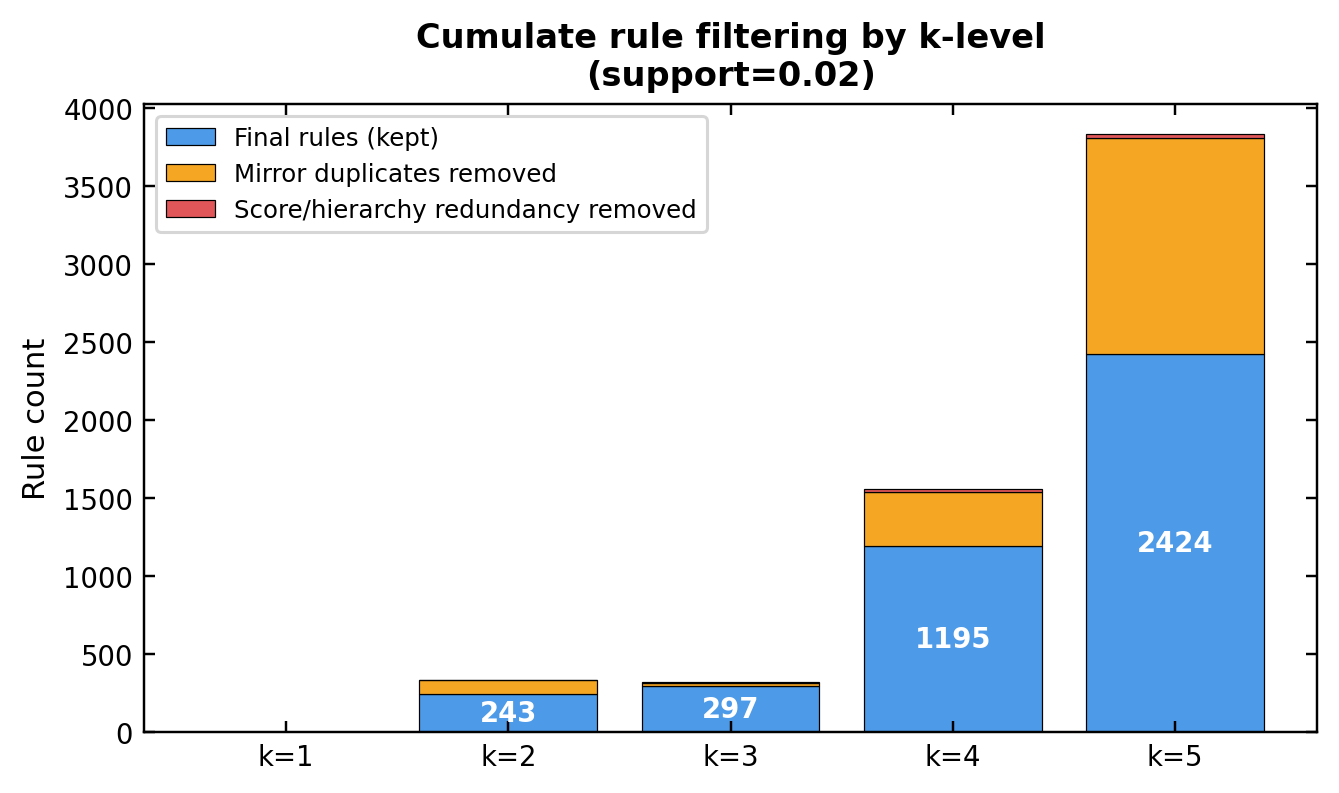

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig08_thesis_redundancy_stacked.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig08_thesis_redundancy_stacked.png')

In [8]:

# Figure 8: Stacked redundancy breakdown, 100k sample.
raw = cum['raw_rules_median'].fillna(0).astype(int).tolist()
score = cum['score_rank_rules_median'].fillna(0).astype(int).tolist()
family = cum['family_dedupe_rules_median'].fillna(0).astype(int).tolist()
final = cum['final_rules_median'].fillna(0).astype(int).tolist()
mirror_removed = [max(0, fml - fin) for fml, fin in zip(family, final)]
score_removed = [max(0, r - sc) for r, sc in zip(raw, score)]

fig, ax = plt.subplots(figsize=(6.2, 3.7))
x = np.arange(len(ks))
ax.bar(x, final, color='#4C9AE8', edgecolor='black', linewidth=0.4, label='Final rules (kept)')
ax.bar(x, mirror_removed, bottom=final, color=COL_ORANGE, edgecolor='black', linewidth=0.4, label='Mirror duplicates removed')
ax.bar(x, score_removed, bottom=np.array(final)+np.array(mirror_removed), color=COL_RED, edgecolor='black', linewidth=0.4, label='Score/hierarchy redundancy removed')
for xi, v in zip(x, final):
    if v > 100:
        ax.text(xi, v/2, f'{v}', color='white', ha='center', va='center', fontweight='bold', fontsize=9)
ax.set_xticks(x, [f'k={k}' for k in ks])
ax.set_ylabel('Rule count')
ax.set_title('Cumulate rule filtering by k-level\n(support=0.02)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, fontsize=8)
paper_axes(ax)
save_show(fig, 'fig08_thesis_redundancy_stacked.png')


## Figure 9

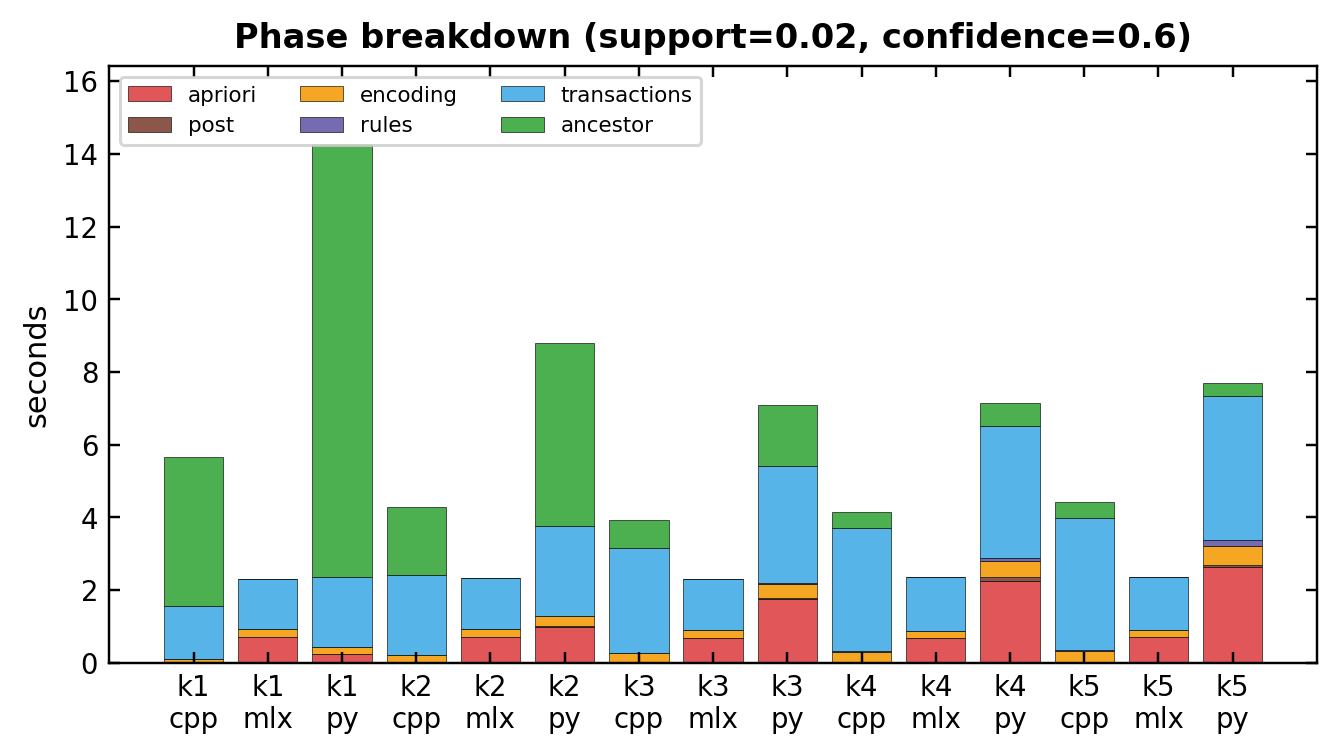

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig09_phase_breakdown_baseline.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig09_phase_breakdown_baseline.png')

In [9]:

# Figure 9: Phase breakdown from old 100k phase benchmark.
# Show runtime_k rows for cpp/mlxtend/python across K.
phase_specs = [('apriori', 'apriori'), ('postprocess', 'post'), ('encode_transactions', 'encoding'), ('association_rules', 'rules'), ('build_transactions', 'transactions'), ('ancestor_map', 'ancestor')]
colors = {'apriori': COL_RED, 'post': '#8C564B', 'encoding': COL_ORANGE, 'rules': '#756BB1', 'transactions': COL_PY, 'ancestor': '#4CAF50'}
impl_order = [('cpp_cumulate', 'cpp'), ('mlxtend_flat', 'mlx'), ('python_cumulate', 'py')]
labels=[]; data={name:[] for _, name in phase_specs}
for k in ks:
    for impl, short in impl_order:
        sub = phase[(phase.experiment == 'runtime_k') & (phase.implementation == impl) & (phase.k_levels == k)]
        if sub.empty:
            continue
        labels.append(f'k{k}\n{short}')
        for phase_name, nice in phase_specs:
            val = sub.loc[sub.phase == phase_name, 'seconds_median']
            data[nice].append(float(val.iloc[0]) if len(val) and pd.notna(val.iloc[0]) else 0.0)
fig, ax = plt.subplots(figsize=(6.2, 3.52))
bottom = np.zeros(len(labels))
for _, nice in phase_specs:
    vals = np.array(data[nice])
    ax.bar(labels, vals, bottom=bottom, label=nice, color=colors[nice], edgecolor='black', linewidth=0.2)
    bottom += vals
ax.set_ylim(0, bottom.max() * 1.15)
ax.set_ylabel('seconds')
ax.set_title('Phase breakdown (support=0.02, confidence=0.6)', fontweight='bold')
ax.legend(ncol=3, loc='upper left', bbox_to_anchor=(0, 1), frameon=True, fontsize=7)
paper_axes(ax)
save_show(fig, 'fig09_phase_breakdown_baseline.png')


## Figures 10–12

## Figure 10

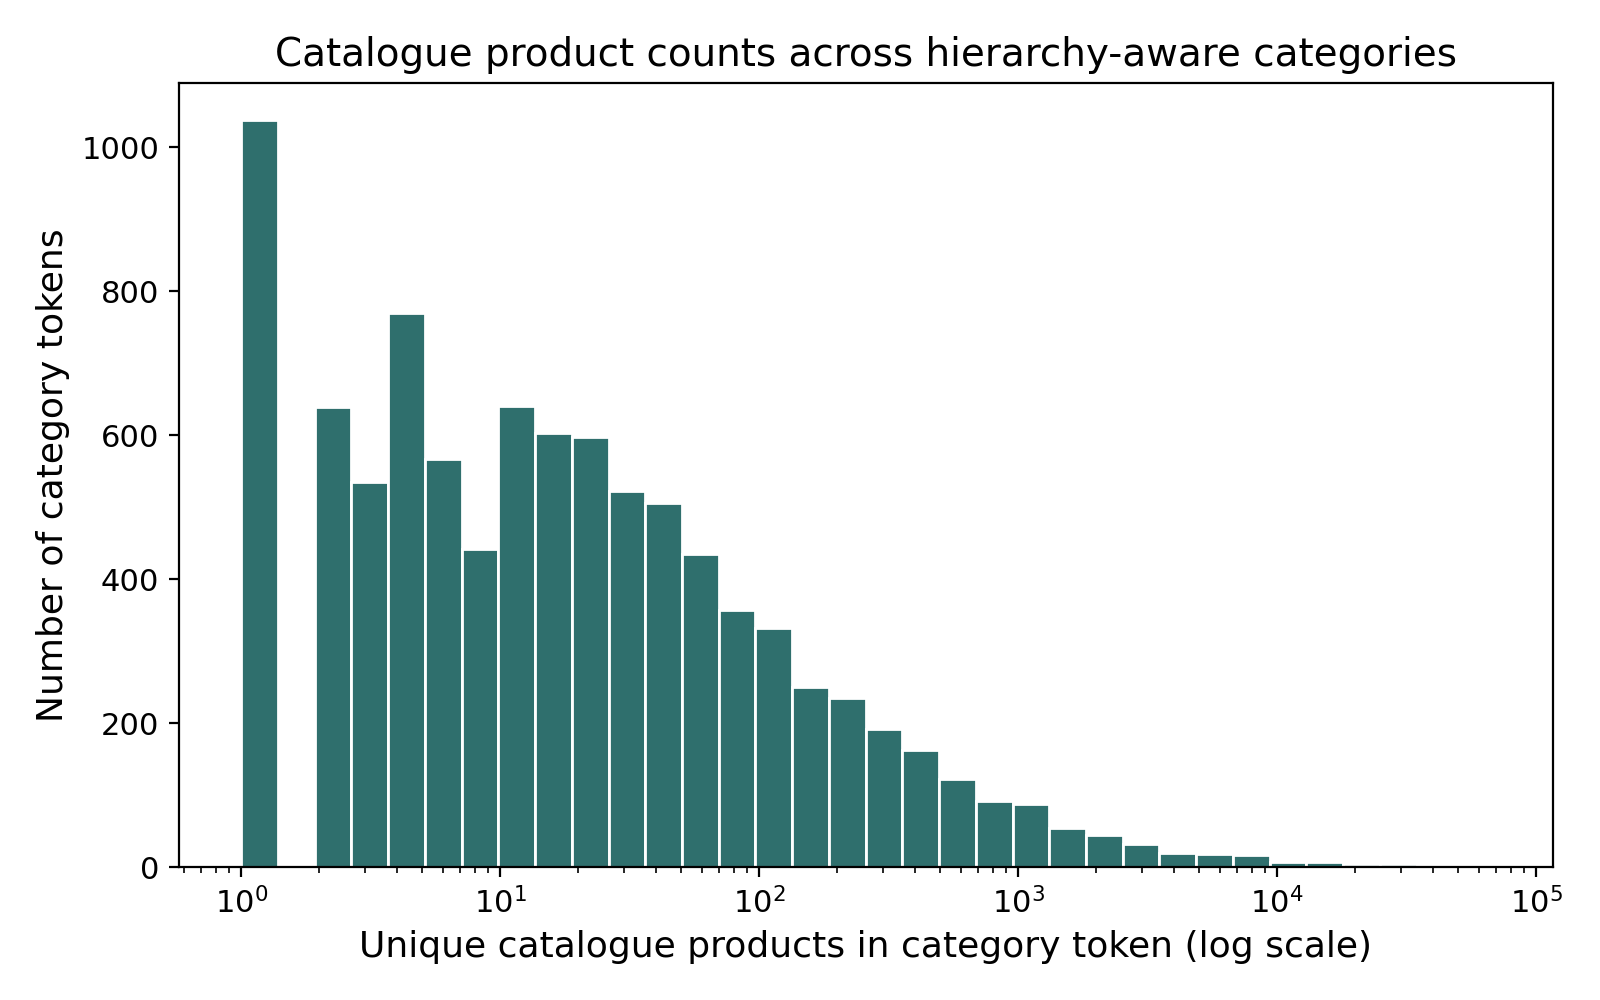

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig10_category_inventory_histogram.png


## Figure 11

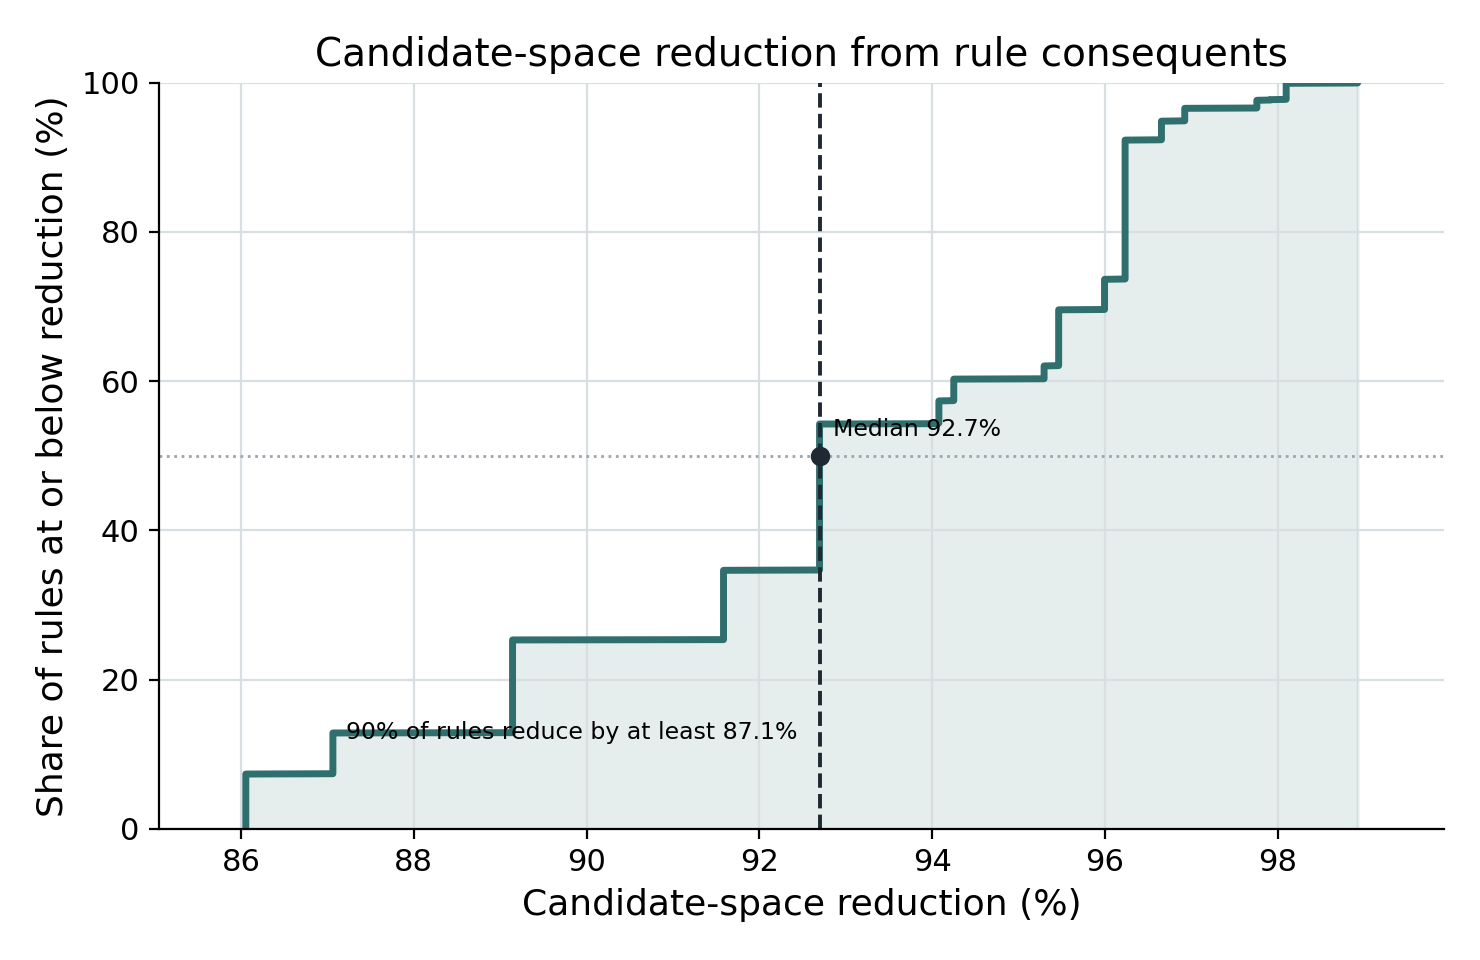

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig11_candidate_space_reduction_from_rule_consequents.png


## Figure 12

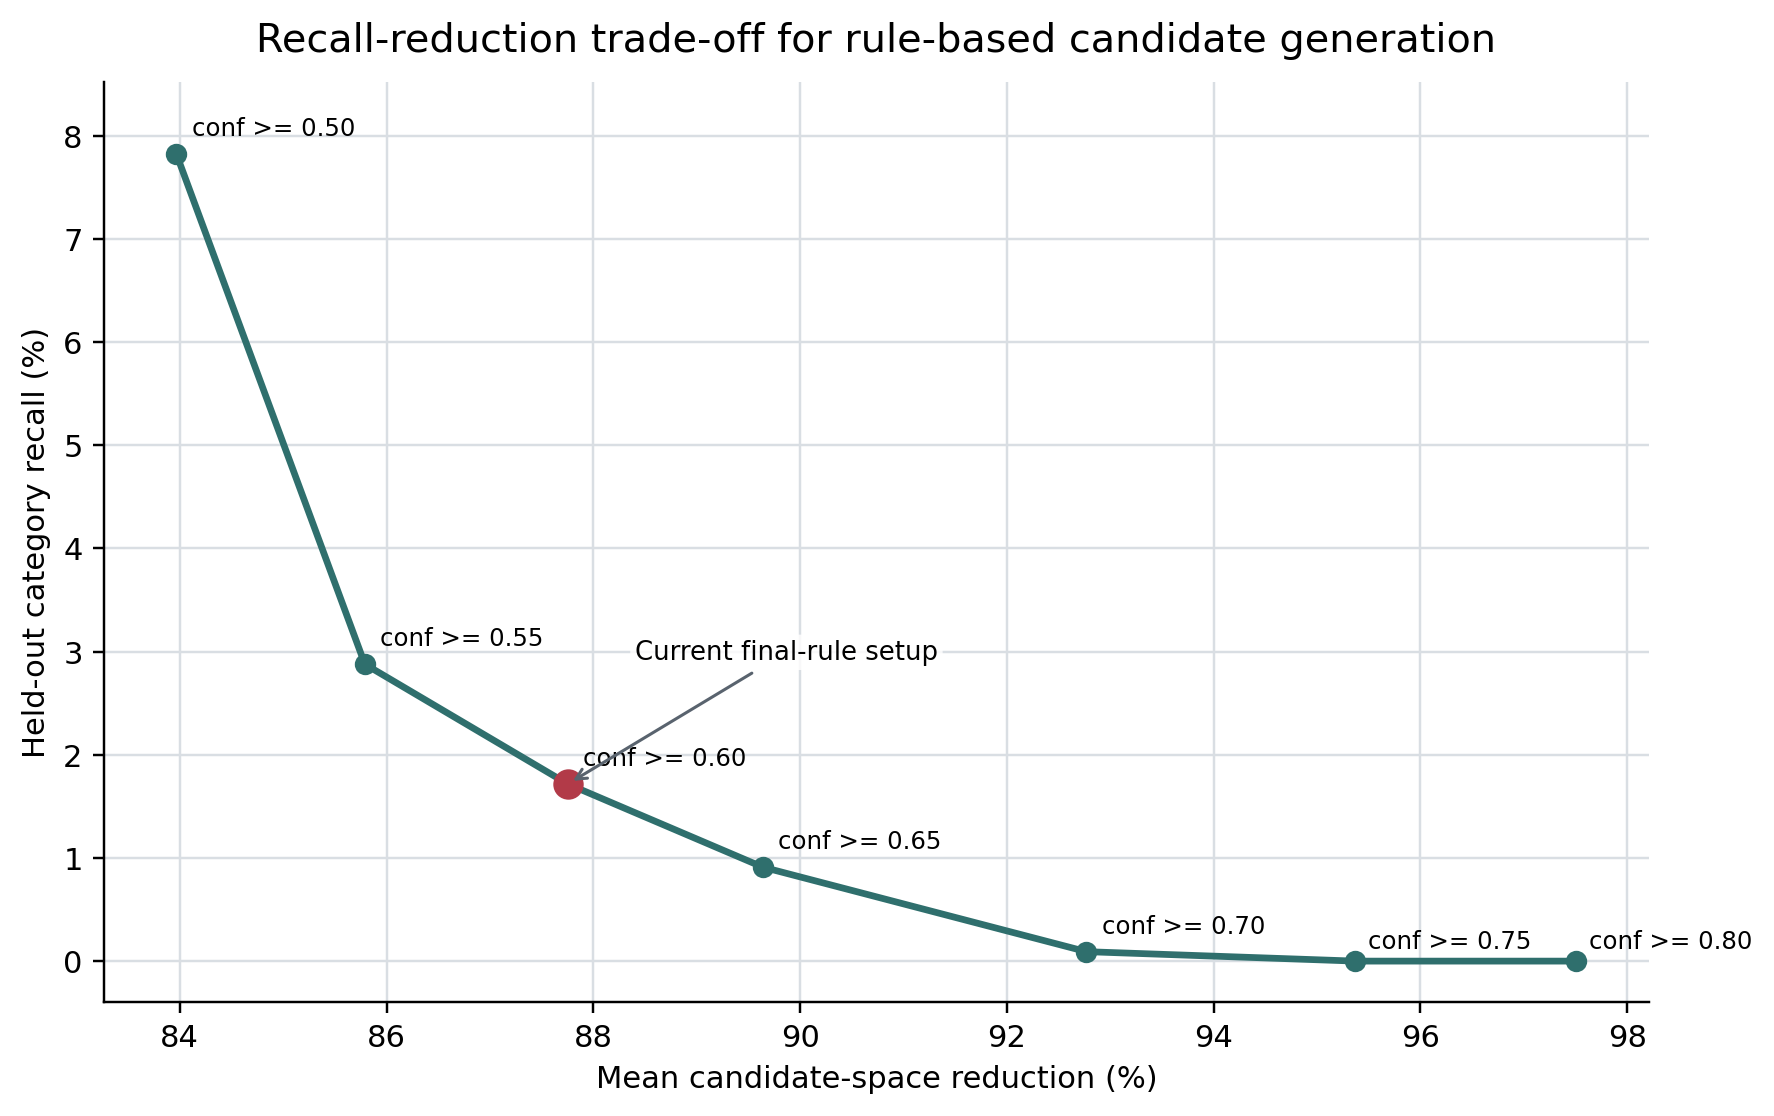

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig12_recall_reduction_tradeoff.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig12_recall_reduction_tradeoff.png')

In [10]:
# Figures 10-11: full-catalogue benchmark images generated from the local full data.
for n, src in [
    (10, RULE_CANDIDATE_DIR / 'category_inventory_histogram.png'),
    (11, RULE_CANDIDATE_DIR / 'candidate_space_reduction_from_rule_consequents.png'),
]:
    display(Markdown(f'## Figure {n}'))
    show_existing(src, f'fig{n:02d}_{src.name}')

# Figure 12: redraw locally so labels stay readable in the thesis figure.
display(Markdown('## Figure 12'))
tradeoff = pd.read_csv(HELD_OUT_DIR / 'recall_reduction_tradeoff.csv')
fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(
    tradeoff['reduction_pct'], tradeoff['held_out_recall_pct'],
    marker='o', linewidth=2.2, color='#2f6f6d',
)
for row in tradeoff.itertuples(index=False):
    label = f'conf >= {row.confidence_threshold:.2f}'
    dx, dy = (0.15, 0.18)
    if row.confidence_threshold >= 0.75:
        dx, dy = (0.12, 0.12)
    ax.text(row.reduction_pct + dx, row.held_out_recall_pct + dy, label, fontsize=8)

final_conf = 0.60
rec = tradeoff.iloc[(tradeoff['confidence_threshold'] - final_conf).abs().argmin()]
ax.scatter([rec['reduction_pct']], [rec['held_out_recall_pct']], s=80, color='#b23a48', zorder=3)
ax.annotate(
    'Current final-rule setup',
    xy=(rec['reduction_pct'], rec['held_out_recall_pct']),
    xytext=(rec['reduction_pct'] + 0.65, rec['held_out_recall_pct'] + 1.15),
    arrowprops={'arrowstyle': '->', 'color': '#59636e', 'lw': 1.0},
    fontsize=8.5,
    ha='left',
    va='bottom',
    bbox={'boxstyle': 'round,pad=0.18', 'fc': 'white', 'ec': 'none', 'alpha': 0.82},
)
ax.set_xlim(tradeoff['reduction_pct'].min() - 0.7, tradeoff['reduction_pct'].max() + 0.7)
ax.set_ylim(-0.4, tradeoff['held_out_recall_pct'].max() + 0.7)
ax.set_xlabel('Mean candidate-space reduction (%)')
ax.set_ylabel('Held-out category recall (%)')
ax.set_title('Recall-reduction trade-off for rule-based candidate generation', fontsize=13, pad=10)
ax.tick_params(labelsize=10)
ax.grid(color='#d9dee3', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
save_show(fig, 'fig12_recall_reduction_tradeoff.png')


## Sanity Checks

In [11]:
# Sanity checks: these should match the thesis narrative and are computed from imported outputs.
print('Figure 2/3 final rules by K:', dict(zip(ks, finals)))
print('Figure 3 mlxtend rules by K:', dict(zip(ks, mlx_rules)))
print('Figure 4 measured K=1 core timings:', dict(runtime_k.loc[1]))
if {'python_cumulate', 'mlxtend_flat'}.issubset(runtime_k.columns) and 1 in runtime_k.index:
    print('Python faster than mlxtend at K=1:', runtime_k.loc[1, 'python_cumulate'] < runtime_k.loc[1, 'mlxtend_flat'])
print('Candidate summary:')
display(pd.read_csv(RULE_CANDIDATE_DIR / 'summary.csv'))
print('Recall/reduction tradeoff:')
display(pd.read_csv(HELD_OUT_DIR / 'recall_reduction_tradeoff.csv'))


Figure 2/3 final rules by K: {1: 2, 2: 243, 3: 297, 4: 1195, 5: 2424}
Figure 3 mlxtend rules by K: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2}
Figure 4 measured K=1 core timings: {'cpp_cumulate': 0.002339205, 'mlxtend_flat': 0.725, 'python_cumulate': 0.25}
Python faster than mlxtend at K=1: True
Candidate summary:


,categorized_products,category_tokens,rules,median_unique_products_per_category,median_consequent_candidate_products,median_candidate_share_pct,median_search_space_reduction_pct,p25_search_space_reduction_pct,p75_search_space_reduction_pct,single_consequent_rules,single_consequent_median_candidate_products,single_consequent_median_candidate_share_pct,single_consequent_median_search_space_reduction_pct
0,476455,9343,2360,14.0,34796.0,7.303103,92.696897,89.143361,96.233642,2326,34796.0,7.303103,92.696897


Recall/reduction tradeoff:


,confidence_threshold,rules,reduction_pct,held_out_recall_pct
0,0.50,528,83.967201,7.818704
1,0.55,414,85.789549,2.877039
2,0.60,325,87.751809,1.716450
3,0.65,215,89.639828,0.910146
4,0.70,144,92.768583,0.091625
5,0.75,81,95.370875,0.000000
6,0.80,36,97.508397,0.000000
